# Naive Bayes Model: Employee Attrition Prediction

1. Train-test split: 80:20 / 70:30 (stratified)
2. Feature set: ทุก feature (baseline) / Direct Variation (11) / Top 10 / Top 20 / Top 21 Most Important
3. วิธีจัดการ class imbalance: ไม่จัดการ (baseline) / ปรับ prior ให้สมดุล / Random Undersampling / Random Oversampling / SMOTE
4. ปรับค่า `var_smoothing` ด้วย Grid Search ในแต่ละ configuration (เลือกด้วย Macro F1 และรายงาน F1 ของแต่ละคลาส)

## IMPORT

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn import metrics
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
RESULTS_DIR = '../results/naive_bayes'
os.makedirs(RESULTS_DIR, exist_ok=True)

## LOAD DATA

In [2]:
NB_data = pd.read_csv('../data/data_preprocess.csv')

# คอลัมน์ one-hot (True/False) แปลงเป็น 0/1 เพื่อให้เป็นตัวเลขทั้งหมด
bool_cols = NB_data.select_dtypes(include='bool').columns
NB_data[bool_cols] = NB_data[bool_cols].astype(int)

print("Data shape:", NB_data.shape)
print("\nFirst 5 rows:")
print(NB_data.head(5))

Data shape: (43439, 38)

First 5 rows:
   age  job_level  tenure_years  salary_usd  salary_vs_market_pct  \
0   26          0      1.871802       70000                   5.2   
1   35          0      0.405465       64000                 -15.5   
2   23          2      1.098612      142000                 -15.9   
3   20          4      1.163151      147000                   2.6   
4   40          2      1.945910      141000                  11.3   

   rto_mandate  days_in_office_required  commute_minutes  prefers_remote  \
0            0                        4         3.806662               1   
1            0                        5         3.891820               1   
2            1                        3         3.583519               1   
3            0                        5         2.833213               0   
4            1                        4         4.025352               1   

   flexibility_importance  ...  department_Engineering  department_Finance  \
0          

## CHECK DATA

In [3]:
print("DATA OVERVIEW")
print(f"Total rows: {len(NB_data)}")
print(f"Total columns: {len(NB_data.columns)}")
print(f"Missing values: {NB_data.isnull().sum().sum()}")
print(f"Non-numeric columns: {list(NB_data.select_dtypes(exclude='number').columns)}")

DATA OVERVIEW
Total rows: 43439
Total columns: 38
Missing values: 0
Non-numeric columns: []


## CHECK TARGET IMBALANCE

In [4]:
print("TARGET CLASS DISTRIBUTION")
print("\nClass counts:")
print(NB_data['attrition'].value_counts())
print("\nClass proportion (%):")
print(NB_data['attrition'].value_counts(normalize=True) * 100)

TARGET CLASS DISTRIBUTION

Class counts:
attrition
0    35508
1     7931
Name: count, dtype: int64

Class proportion (%):
attrition
0    81.742213
1    18.257787
Name: proportion, dtype: float64


## SELECT FEATURE SETS

In [5]:
corr = NB_data.corr(numeric_only=True)['attrition'].drop('attrition')
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

corr_df = pd.DataFrame({
    'Correlation': corr,
    'Abs_Correlation': corr.abs(),
    'Direction': corr.apply(lambda v: 'แปรผันตรง (+)' if v > 0 else 'แปรผกผัน (−)'),
})
corr_df.index.name = 'Feature'
corr_df.insert(0, 'Rank', range(1, len(corr_df) + 1))
print(corr_df.round(4).to_string())

                             Rank  Correlation  Abs_Correlation      Direction
Feature                                                                       
days_in_office_required         1       0.2605           0.2605  แปรผันตรง (+)
manager_relationship_score      2      -0.2350           0.2350   แปรผกผัน (−)
work_arrangement_onsite         3       0.2317           0.2317  แปรผันตรง (+)
engagement_score                4      -0.2005           0.2005   แปรผกผัน (−)
rto_mandate                     5       0.1953           0.1953  แปรผันตรง (+)
burnout_score                   6       0.1314           0.1314  แปรผันตรง (+)
work_arrangement_remote         7      -0.1114           0.1114   แปรผกผัน (−)
work_arrangement_hybrid         8      -0.1065           0.1065   แปรผกผัน (−)
salary_vs_market_pct            9      -0.0938           0.0938   แปรผกผัน (−)
career_growth_score            10      -0.0736           0.0736   แปรผกผัน (−)
tenure_years                   11      -0.0673      

In [6]:
Direct_Variation_FEATURES = [
    'days_in_office_required',
    'work_arrangement_onsite',
    'rto_mandate',
    'burnout_score',
    'prefers_remote',
    'commute_minutes',
    'recent_layoff_round',
    'after_hours_work',
    'job_level',
    'salary_usd',
    'weekly_hours',
    'salary_vs_level'
]

ALL_FEATURES = [c for c in NB_data.columns if c != 'attrition']

Top_10_Most_IMPORTANT_FEATURES = [
    'days_in_office_required',
    'manager_relationship_score',
    'work_arrangement_onsite',
    'engagement_score',
    'rto_mandate',
    'burnout_score',
    'work_arrangement_remote',
    'work_arrangement_hybrid',
    'salary_vs_market_pct',
    'career_growth_score',
]

Top_20_Most_IMPORTANT_FEATURES = [
    'days_in_office_required',
    'manager_relationship_score',
    'work_arrangement_onsite',
    'engagement_score',
    'rto_mandate',
    'burnout_score',
    'work_arrangement_remote',
    'work_arrangement_hybrid',
    'salary_vs_market_pct',
    'career_growth_score',
    'tenure_years',
    'ai_tools_adoption',
    'prefers_remote',
    'manager_1on1_per_month',
    'commute_minutes',
    'recent_layoff_round',
    'promotions_last_2y',
    'after_hours_work',
    'age',
    'job_level',
]

Top_22_Most_IMPORTANT_FEATURES = [
    'days_in_office_required',
    'manager_relationship_score',
    'work_arrangement_onsite',
    'engagement_score',
    'rto_mandate',
    'burnout_score',
    'work_arrangement_remote',
    'work_arrangement_hybrid',
    'salary_vs_market_pct',
    'career_growth_score',
    'tenure_years',
    'ai_tools_adoption',
    'prefers_remote',
    'manager_1on1_per_month',
    'commute_minutes',
    'recent_layoff_round',
    'promotions_last_2y',
    'after_hours_work',
    'age',
    'job_level',
    'salary_usd',
    'weekly_hours',
]

FEATURE_SETS = {
    'All features': ALL_FEATURES,
    'Direct Variation features': Direct_Variation_FEATURES,
    'Top 10 Most Important features': Top_10_Most_IMPORTANT_FEATURES,
    'Top 20 Most Important features': Top_20_Most_IMPORTANT_FEATURES,
    'Top 22 Most Important features': Top_22_Most_IMPORTANT_FEATURES,
}

X = NB_data[ALL_FEATURES]
y = NB_data['attrition']

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)} features")
print("\nAll features:", ALL_FEATURES)

All features: 37 features
Direct Variation features: 12 features
Top 10 Most Important features: 10 features
Top 20 Most Important features: 20 features
Top 22 Most Important features: 22 features

All features: ['age', 'job_level', 'tenure_years', 'salary_usd', 'salary_vs_market_pct', 'rto_mandate', 'days_in_office_required', 'commute_minutes', 'prefers_remote', 'flexibility_importance', 'ai_tools_adoption', 'weekly_hours', 'after_hours_work', 'burnout_score', 'manager_relationship_score', 'manager_1on1_per_month', 'engagement_score', 'promotions_last_2y', 'career_growth_score', 'recent_layoff_round', 'team_size', 'salary_vs_level', 'gender_Female', 'gender_Male', 'gender_Other', 'department_Customer Support', 'department_Data', 'department_Engineering', 'department_Finance', 'department_HR', 'department_Marketing', 'department_Operations', 'department_Product', 'department_Sales', 'work_arrangement_hybrid', 'work_arrangement_onsite', 'work_arrangement_remote']


## TRAIN-TEST SPLIT

แบ่งข้อมูล 2 แบบเพื่อเปรียบเทียบ: **80:20** และ **70:30** (stratified, `random_state=42`)
* Grid Search + 5-Fold CV ทำบน training set ของแต่ละ split แยกกัน
* test set ของแต่ละ split ใช้ประเมินผลครั้งสุดท้ายเท่านั้น

In [7]:
SPLIT_RATIOS = {
    '80:20': 0.2,
    '70:30': 0.3,
}

SPLITS = {}
for split_name, test_size in SPLIT_RATIOS.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )
    SPLITS[split_name] = (X_tr, X_te, y_tr, y_te)

    print(f"TRAIN-TEST SPLIT {split_name} (Stratified)")
    print(f"  Training set size: {X_tr.shape[0]}  (No Attrition={(y_tr == 0).sum()}, Attrition={(y_tr == 1).sum()})")
    print(f"  Test set size:     {X_te.shape[0]}  (No Attrition={(y_te == 0).sum()}, Attrition={(y_te == 1).sum()})\n")

TRAIN-TEST SPLIT 80:20 (Stratified)
  Training set size: 34751  (No Attrition=28406, Attrition=6345)
  Test set size:     8688  (No Attrition=7102, Attrition=1586)

TRAIN-TEST SPLIT 70:30 (Stratified)
  Training set size: 30407  (No Attrition=24855, Attrition=5552)
  Test set size:     13032  (No Attrition=10653, Attrition=2379)



## DEFINE PIPELINES

| Strategy | Pipeline | หลักการ |
| :--- | :--- | :--- |
| Baseline | Scaler → GaussianNB | ใช้ข้อมูลตามสัดส่วนจริง (~82:18) |
| Balanced Prior | Scaler → GaussianNB(priors=[0.5, 0.5]) | ไม่แตะข้อมูล เปลี่ยน prior ให้สองคลาสเท่ากัน |
| Random Undersampling | Scaler → RandomUnderSampler → GaussianNB | สุ่ม**ตัด**คลาส No Attrition ทิ้งจนเหลือเท่าคลาส Attrition (50:50) ข้อมูลเทรนลดลงมาก |
| Random Oversampling | Scaler → RandomOverSampler → GaussianNB | สุ่ม**ทำซ้ำ**แถวของคลาส Attrition จนเท่าคลาส No Attrition (50:50) ไม่มีข้อมูลใหม่ |
| SMOTE | Scaler → SMOTE → GaussianNB | **สังเคราะห์**แถวใหม่ของคลาส Attrition จากการประมาณค่าระหว่างเพื่อนบ้านใกล้เคียง |

การ resample ทุกแบบอยู่ใน `ImbPipeline` จึงทำเฉพาะใน training fold ของ CV เท่านั้น validation fold และ test set ยังคงสัดส่วนจริง

In [8]:
def build_pipeline(strategy):
    if strategy == 'Baseline':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('nb', GaussianNB())
        ])
    if strategy == 'Balanced Prior':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('nb', GaussianNB(priors=[0.5, 0.5]))
        ])
    if strategy == 'Random Undersampling':
        return ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('nb', GaussianNB())
        ])
    if strategy == 'Random Oversampling':
        return ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('nb', GaussianNB())
        ])
    if strategy == 'SMOTE':
        return ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('nb', GaussianNB())
        ])
    raise ValueError(strategy)

STRATEGIES = ['Baseline', 'Balanced Prior', 'Random Undersampling', 'Random Oversampling', 'SMOTE']

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

var_smoothing_values = np.logspace(-12, 2, 15)

## EXPERIMENT: SPLIT × FEATURE SET × IMBALANCE STRATEGY × VAR_SMOOTHING

In [9]:
# Macro F1 ใช้เลือกโมเดล (refit) ส่วน F1 รายคลาสเก็บไว้ประเมินผล
SCORING = {
    'macro_f1': 'f1_macro',
    'f1_no_attrition': make_scorer(f1_score, pos_label=0),
    'f1_attrition': make_scorer(f1_score, pos_label=1),
}

experiment_results = []
smoothing_results = []
search_objects = {}

for split_name, (X_train, X_test, y_train, y_test) in SPLITS.items():
  for fs_name, fs_cols in FEATURE_SETS.items():
    for strategy in STRATEGIES:
        search = GridSearchCV(
            build_pipeline(strategy),
            param_grid={'nb__var_smoothing': var_smoothing_values},
            scoring=SCORING,
            refit='macro_f1',
            cv=cv,
            n_jobs=-1
        )
        search.fit(X_train[fs_cols], y_train)
        search_objects[(split_name, fs_name, strategy)] = search

        res = search.cv_results_
        best_idx = search.best_index_
        experiment_results.append({
            'Split': split_name,
            'Feature_Set': fs_name,
            'Strategy': strategy,
            'N_Features': len(fs_cols),
            'Best_Var_Smoothing': search.best_params_['nb__var_smoothing'],
            'CV_Macro_F1_Mean': res['mean_test_macro_f1'][best_idx],
            'CV_Macro_F1_Std': res['std_test_macro_f1'][best_idx],
            'CV_F1_No_Attrition_Mean': res['mean_test_f1_no_attrition'][best_idx],
            'CV_F1_No_Attrition_Std': res['std_test_f1_no_attrition'][best_idx],
            'CV_F1_Attrition_Mean': res['mean_test_f1_attrition'][best_idx],
            'CV_F1_Attrition_Std': res['std_test_f1_attrition'][best_idx],
        })

        for i, vs in enumerate(var_smoothing_values):
            smoothing_results.append({
                'Split': split_name,
                'Feature_Set': fs_name,
                'Strategy': strategy,
                'Var_Smoothing': vs,
                'CV_Macro_F1': res['mean_test_macro_f1'][i],
                'CV_F1_No_Attrition': res['mean_test_f1_no_attrition'][i],
                'CV_F1_Attrition': res['mean_test_f1_attrition'][i],
            })

        best_vs = search.best_params_['nb__var_smoothing']
        print(f"{split_name} | {fs_name:30s} | {strategy:20s} | var_smoothing={best_vs:.0e} "
              f"| Macro F1={search.best_score_:.4f} "
              f"| F1 No Attr={res['mean_test_f1_no_attrition'][best_idx]:.4f} "
              f"| F1 Attr={res['mean_test_f1_attrition'][best_idx]:.4f}")

experiment_results_df = (
    pd.DataFrame(experiment_results)
    .sort_values('CV_Macro_F1_Mean', ascending=False)
    .reset_index(drop=True)
)
smoothing_results_df = pd.DataFrame(smoothing_results)

80:20 | All features                   | Baseline             | var_smoothing=1e-02 | Macro F1=0.6906 | F1 No Attr=0.8865 | F1 Attr=0.4947
80:20 | All features                   | Balanced Prior       | var_smoothing=1e-12 | Macro F1=0.6455 | F1 No Attr=0.8037 | F1 Attr=0.4872
80:20 | All features                   | Random Undersampling | var_smoothing=1e-12 | Macro F1=0.6445 | F1 No Attr=0.8029 | F1 Attr=0.4862
80:20 | All features                   | Random Oversampling  | var_smoothing=1e-02 | Macro F1=0.6445 | F1 No Attr=0.8027 | F1 Attr=0.4863
80:20 | All features                   | SMOTE                | var_smoothing=1e-05 | Macro F1=0.6608 | F1 No Attr=0.8285 | F1 Attr=0.4931
80:20 | Direct Variation features      | Baseline             | var_smoothing=1e-03 | Macro F1=0.6297 | F1 No Attr=0.8782 | F1 Attr=0.3812
80:20 | Direct Variation features      | Balanced Prior       | var_smoothing=1e+02 | Macro F1=0.6154 | F1 No Attr=0.7893 | F1 Attr=0.4415
80:20 | Direct Variation fe

## COMPARE ALL EXPERIMENTS

In [10]:
print("COMPARISON: ALL EXPERIMENTS (5-Fold CV Results)\n")
print(experiment_results_df.to_string(index=False))

# ตารางเทียบ Feature Set × Strategy (CV Macro F1)
feature_set_comparison = experiment_results_df.pivot(
    index=['Split', 'Feature_Set'], columns='Strategy', values='CV_Macro_F1_Mean'
).reindex(columns=STRATEGIES)
print("\nCV Macro F1: Split × Feature Set × Strategy\n")
print(feature_set_comparison.round(4).to_string())

# ตารางเทียบ Feature Set × Strategy (CV F1 ของคลาส Attrition)
attrition_f1_comparison = experiment_results_df.pivot(
    index=['Split', 'Feature_Set'], columns='Strategy', values='CV_F1_Attrition_Mean'
).reindex(columns=STRATEGIES)
print("\nCV F1 (Attrition): Split × Feature Set × Strategy\n")
print(attrition_f1_comparison.round(4).to_string())

# ตารางเทียบ split: configuration ที่ดีที่สุดของแต่ละ split
best_per_split = (
    experiment_results_df
    .sort_values('CV_Macro_F1_Mean', ascending=False)
    .groupby('Split', sort=False).head(1)
    .reset_index(drop=True)
)
print("\nBest configuration per split (CV)\n")
print(best_per_split[['Split', 'Feature_Set', 'Strategy', 'Best_Var_Smoothing',
                      'CV_Macro_F1_Mean', 'CV_F1_No_Attrition_Mean', 'CV_F1_Attrition_Mean']]
      .round(4).to_string(index=False))

COMPARISON: ALL EXPERIMENTS (5-Fold CV Results)

Split                    Feature_Set             Strategy  N_Features  Best_Var_Smoothing  CV_Macro_F1_Mean  CV_Macro_F1_Std  CV_F1_No_Attrition_Mean  CV_F1_No_Attrition_Std  CV_F1_Attrition_Mean  CV_F1_Attrition_Std
80:20 Top 22 Most Important features             Baseline          22        1.000000e-02          0.692823         0.009112                 0.887840                0.004247              0.497806             0.014138
80:20 Top 20 Most Important features             Baseline          20        1.000000e-02          0.691320         0.008751                 0.887138                0.003890              0.495501             0.013738
70:30 Top 22 Most Important features             Baseline          22        1.000000e-01          0.691171         0.005821                 0.891696                0.002432              0.490645             0.010592
70:30 Top 20 Most Important features             Baseline          20        1.0000

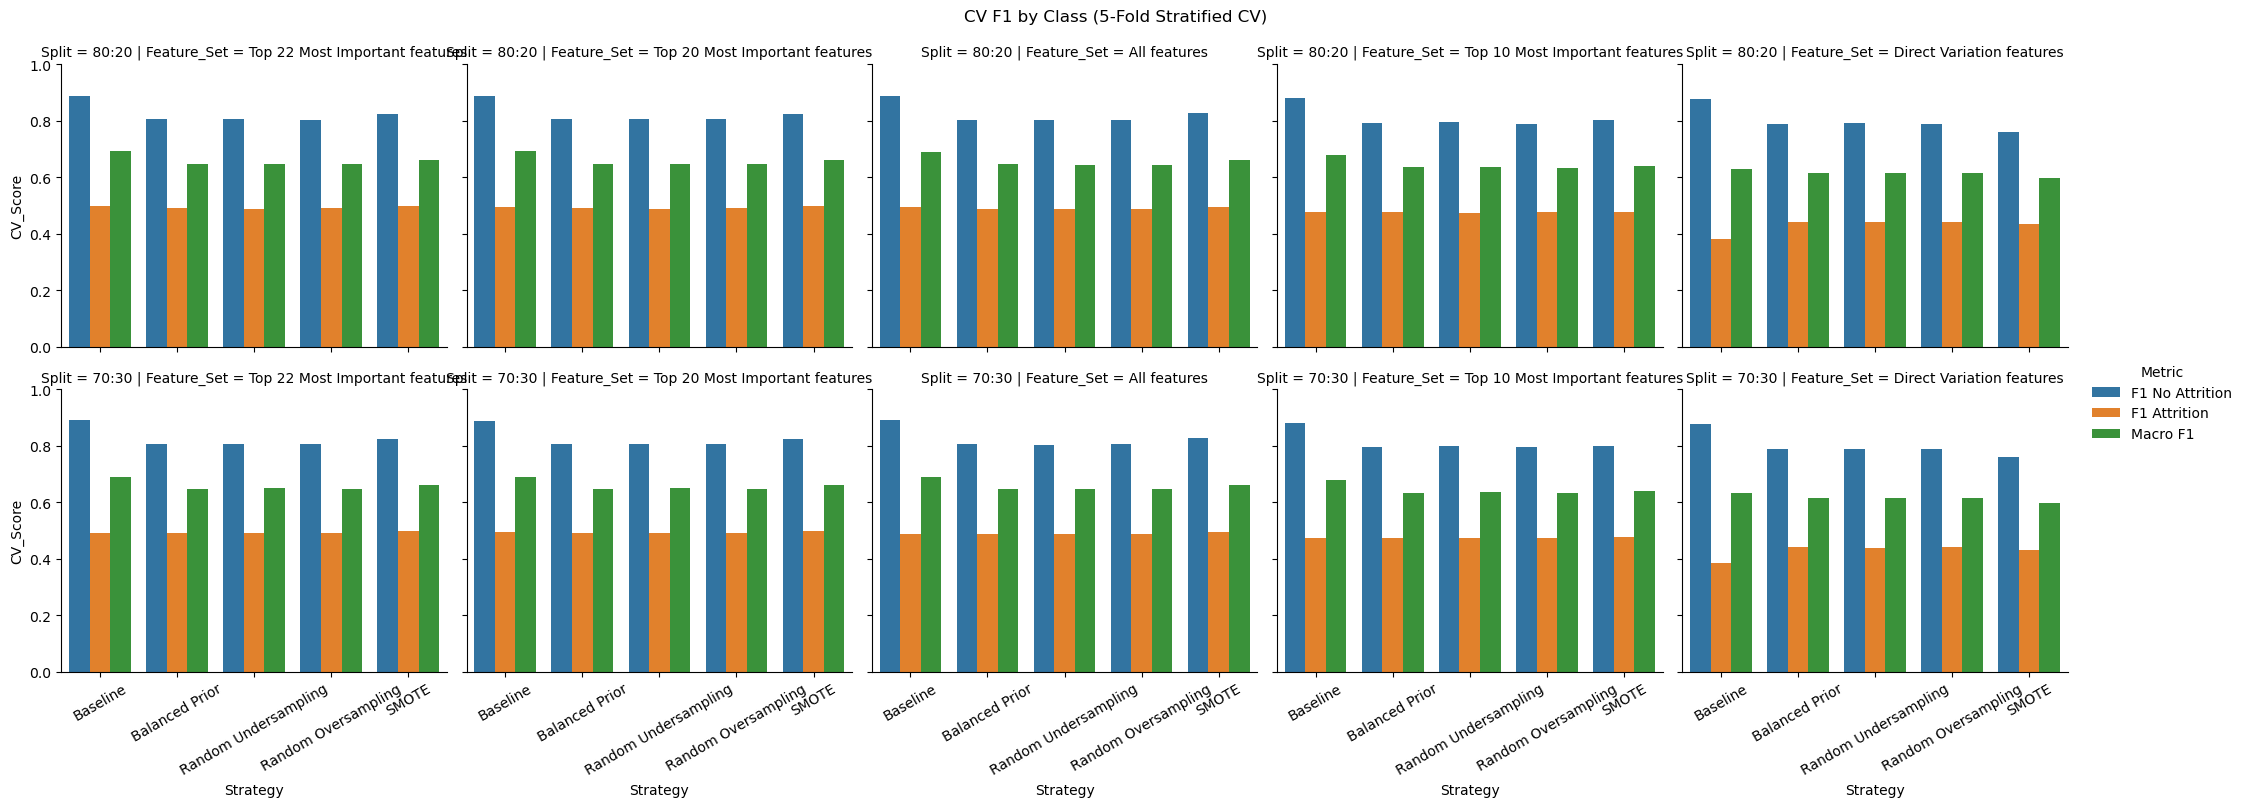

In [11]:
# F1 รายคลาสของแต่ละ configuration
per_class_plot = experiment_results_df.melt(
    id_vars=['Split', 'Feature_Set', 'Strategy'],
    value_vars=['CV_F1_No_Attrition_Mean', 'CV_F1_Attrition_Mean', 'CV_Macro_F1_Mean'],
    var_name='Metric', value_name='CV_Score'
)
per_class_plot['Metric'] = per_class_plot['Metric'].map({
    'CV_F1_No_Attrition_Mean': 'F1 No Attrition',
    'CV_F1_Attrition_Mean': 'F1 Attrition',
    'CV_Macro_F1_Mean': 'Macro F1',
})

g = sns.catplot(
    data=per_class_plot, kind='bar',
    x='Strategy', y='CV_Score', hue='Metric', col='Feature_Set', row='Split',
    order=STRATEGIES, height=3.5, aspect=1.2
)
g.set(ylim=(0, 1))
g.tick_params(axis='x', rotation=30)
g.fig.suptitle("CV F1 by Class (5-Fold Stratified CV)", y=1.03)
plt.show()

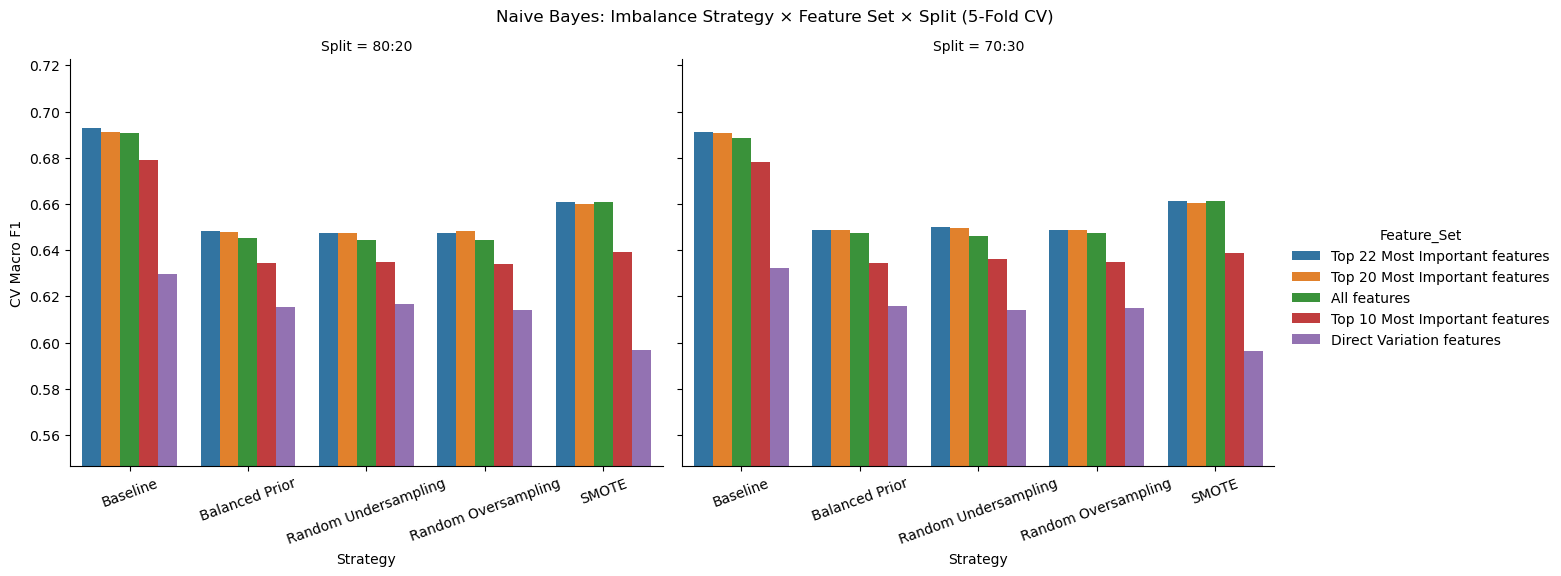

In [12]:
g = sns.catplot(
    data=experiment_results_df, kind='bar',
    x='Strategy', y='CV_Macro_F1_Mean', hue='Feature_Set', col='Split',
    order=STRATEGIES, height=5, aspect=1.3
)
g.set(ylim=(
    experiment_results_df['CV_Macro_F1_Mean'].min() - 0.05,
    experiment_results_df['CV_Macro_F1_Mean'].max() + 0.03
))
g.set_axis_labels("Strategy", "CV Macro F1")
g.tick_params(axis='x', rotation=20)
g.fig.suptitle("Naive Bayes: Imbalance Strategy × Feature Set × Split (5-Fold CV)", y=1.03)
plt.show()

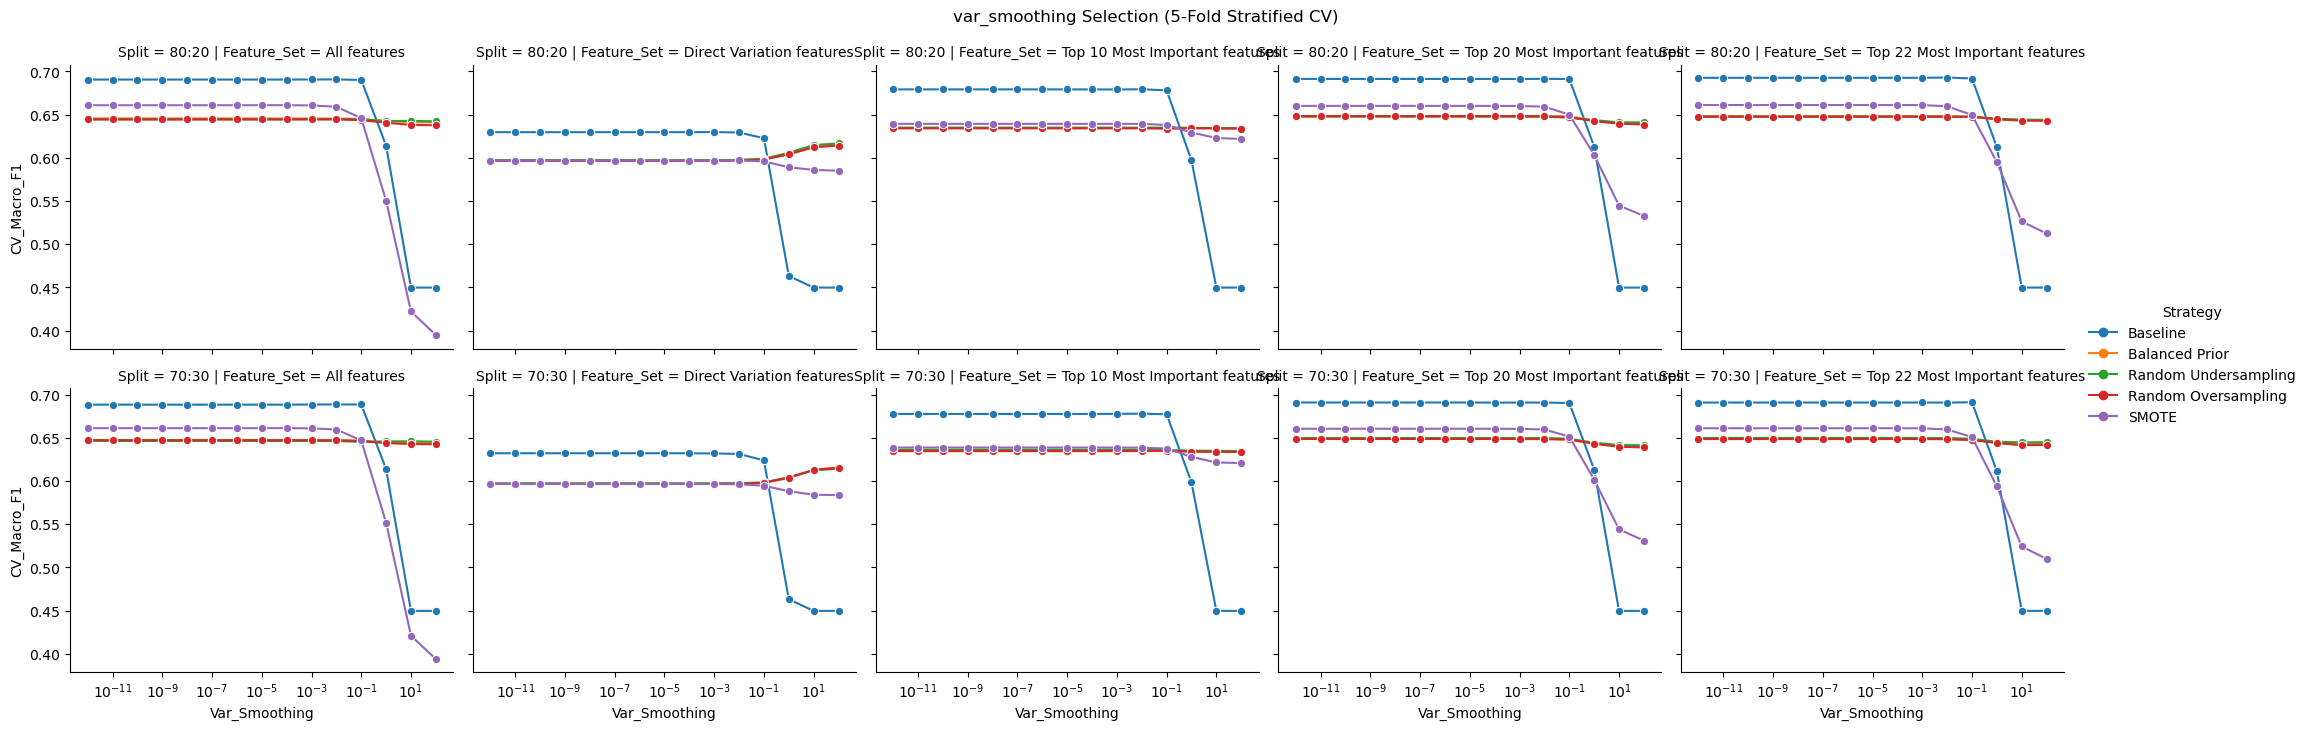

In [13]:
g = sns.relplot(
    data=smoothing_results_df,
    x='Var_Smoothing',
    y='CV_Macro_F1',
    hue='Strategy',
    col='Feature_Set',
    row='Split',
    kind='line',
    marker='o',
    height=3.5,
    aspect=1.2
)
g.set(xscale='log')
g.fig.suptitle("var_smoothing Selection (5-Fold Stratified CV)", y=1.03)
plt.show()

## SELECT BEST MODEL

In [14]:
best_row = experiment_results_df.iloc[0]
best_split = best_row['Split']
best_feature_set = best_row['Feature_Set']
best_strategy = best_row['Strategy']
best_features = FEATURE_SETS[best_feature_set]
best_var_smoothing = best_row['Best_Var_Smoothing']

final_pipeline = search_objects[(best_split, best_feature_set, best_strategy)].best_estimator_

# ใช้ train/test ของ split ที่ชนะ สำหรับ cell ถัดไปทั้งหมด
X_train, X_test, y_train, y_test = SPLITS[best_split]

print("SELECT BEST MODEL")
print(f"\nSelected: Gaussian NB | Split {best_split} | {best_strategy} | {best_feature_set}")
print(f"  Features: {len(best_features)}")
print(f"  var_smoothing: {best_var_smoothing:.0e}")
print(f"  CV Macro F1:          {best_row['CV_Macro_F1_Mean']:.4f} (±{best_row['CV_Macro_F1_Std']:.4f})")
print(f"  CV F1 No Attrition:   {best_row['CV_F1_No_Attrition_Mean']:.4f} (±{best_row['CV_F1_No_Attrition_Std']:.4f})")
print(f"  CV F1 Attrition:      {best_row['CV_F1_Attrition_Mean']:.4f} (±{best_row['CV_F1_Attrition_Std']:.4f})")

SELECT BEST MODEL

Selected: Gaussian NB | Split 80:20 | Baseline | Top 22 Most Important features
  Features: 22
  var_smoothing: 1e-02
  CV Macro F1:          0.6928 (±0.0091)
  CV F1 No Attrition:   0.8878 (±0.0042)
  CV F1 Attrition:      0.4978 (±0.0141)


## COMPARE SPLITS ON TEST SET

นำ configuration ที่ดีที่สุดของแต่ละ split มาวัดผลบน test set ของ split นั้น
* ขนาด test set ต่างกัน (20% กับ 30%) ผล test ของสอง split จึงไม่ได้วัดบนข้อมูลชุดเดียวกัน
* การเลือกโมเดลยังใช้ CV Macro F1 เป็นหลัก ตาราง test นี้ใช้ดูความสอดคล้องระหว่าง CV กับ test

Split                    Feature_Set Strategy  Train_Size  Test_Size  CV_Macro_F1  Test_Accuracy  Test_Macro_F1  Test_F1_No_Attrition  Test_F1_Attrition  Test_Balanced_Accuracy  Test_ROC_AUC
80:20 Top 22 Most Important features Baseline       34751       8688       0.6928         0.8193         0.7008                0.8891             0.5124                  0.7031        0.8099
70:30 Top 22 Most Important features Baseline       30407      13032       0.6912         0.8233         0.6961                0.8927             0.4995                  0.6911        0.8120


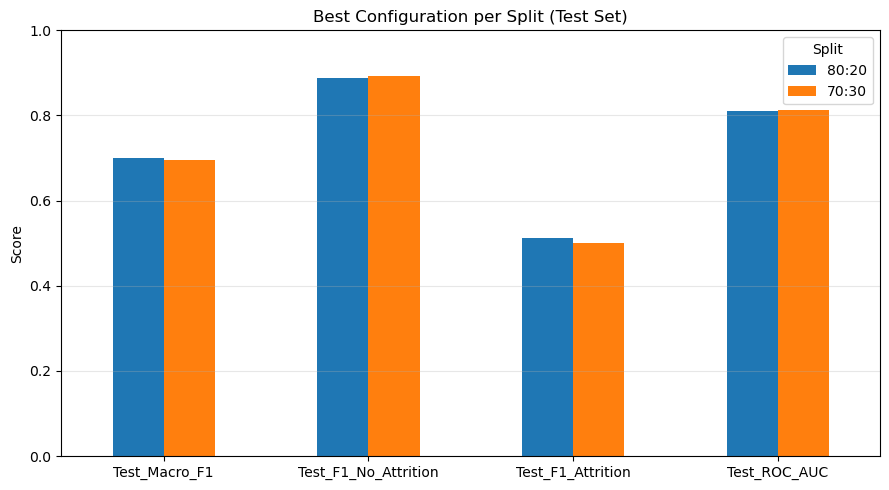

In [15]:
split_test_rows = []
for _, row in best_per_split.iterrows():
    X_tr, X_te, y_tr, y_te = SPLITS[row['Split']]
    cols = FEATURE_SETS[row['Feature_Set']]
    model = search_objects[(row['Split'], row['Feature_Set'], row['Strategy'])].best_estimator_
    pred = model.predict(X_te[cols])
    prob = model.predict_proba(X_te[cols])[:, 1]
    split_test_rows.append({
        'Split': row['Split'],
        'Feature_Set': row['Feature_Set'],
        'Strategy': row['Strategy'],
        'Train_Size': len(y_tr),
        'Test_Size': len(y_te),
        'CV_Macro_F1': row['CV_Macro_F1_Mean'],
        'Test_Accuracy': accuracy_score(y_te, pred),
        'Test_Macro_F1': f1_score(y_te, pred, average='macro'),
        'Test_F1_No_Attrition': f1_score(y_te, pred, pos_label=0),
        'Test_F1_Attrition': f1_score(y_te, pred, pos_label=1),
        'Test_Balanced_Accuracy': balanced_accuracy_score(y_te, pred),
        'Test_ROC_AUC': roc_auc_score(y_te, prob),
    })

split_test_comparison = pd.DataFrame(split_test_rows)
print(split_test_comparison.round(4).to_string(index=False))

split_test_comparison.set_index('Split')[
    ['Test_Macro_F1', 'Test_F1_No_Attrition', 'Test_F1_Attrition', 'Test_ROC_AUC']
].T.plot(kind='bar', figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.title("Best Configuration per Split (Test Set)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## FINAL TEST SET EVALUATION

In [16]:
final_pipeline.fit(X_train[best_features], y_train)

y_pred = final_pipeline.predict(X_test[best_features])
y_prob = final_pipeline.predict_proba(X_test[best_features])[:, 1]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nTest Set Metrics:")
print(f"  Accuracy:           {accuracy:.4f}")
print(f"  Precision:          {precision:.4f}")
print(f"  Recall:             {recall:.4f}")
print(f"  F1-score:           {f1:.4f}")
print(f"  Macro F1:           {macro_f1:.4f}")
print(f"  Balanced Accuracy:  {balanced_acc:.4f}")
print(f"  ROC-AUC:            {roc_auc:.4f}")


Test Set Metrics:
  Accuracy:           0.8193
  Precision:          0.5049
  Recall:             0.5202
  F1-score:           0.5124
  Macro F1:           0.7008
  Balanced Accuracy:  0.7031
  ROC-AUC:            0.8099


In [18]:
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

              precision    recall  f1-score   support

No Attrition       0.89      0.89      0.89      7102
   Attrition       0.50      0.52      0.51      1586

    accuracy                           0.82      8688
   macro avg       0.70      0.70      0.70      8688
weighted avg       0.82      0.82      0.82      8688



Confusion Matrix:
[[6293  809]
 [ 761  825]]


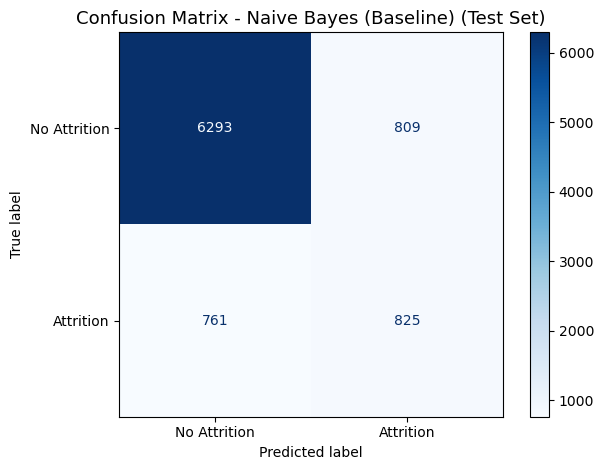

In [19]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=['No Attrition', 'Attrition']
)
cm_display.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Naive Bayes ({best_strategy}) (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

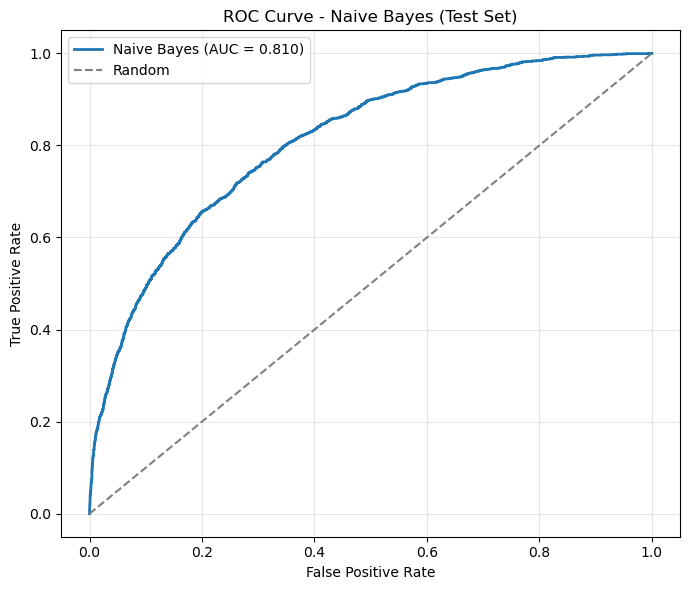

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Naive Bayes (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## FEATURE INSIGHT

                   Feature  Mean_No_Attrition  Mean_Attrition  Mean_Difference
   days_in_office_required          -0.122860        0.550034         0.672894
manager_relationship_score           0.110958       -0.496747        -0.607705
   work_arrangement_onsite          -0.108974        0.487866         0.596840
          engagement_score           0.094705       -0.423985        -0.518690
               rto_mandate          -0.091873        0.411307         0.503180
             burnout_score          -0.061894        0.277092         0.338985
   work_arrangement_remote           0.052628       -0.235609        -0.288237
   work_arrangement_hybrid           0.049906       -0.223424        -0.273330
      salary_vs_market_pct           0.042951       -0.192288        -0.235239
       career_growth_score           0.033606       -0.150449        -0.184055
              tenure_years           0.031785       -0.142299        -0.174084
         ai_tools_adoption           0.029080       

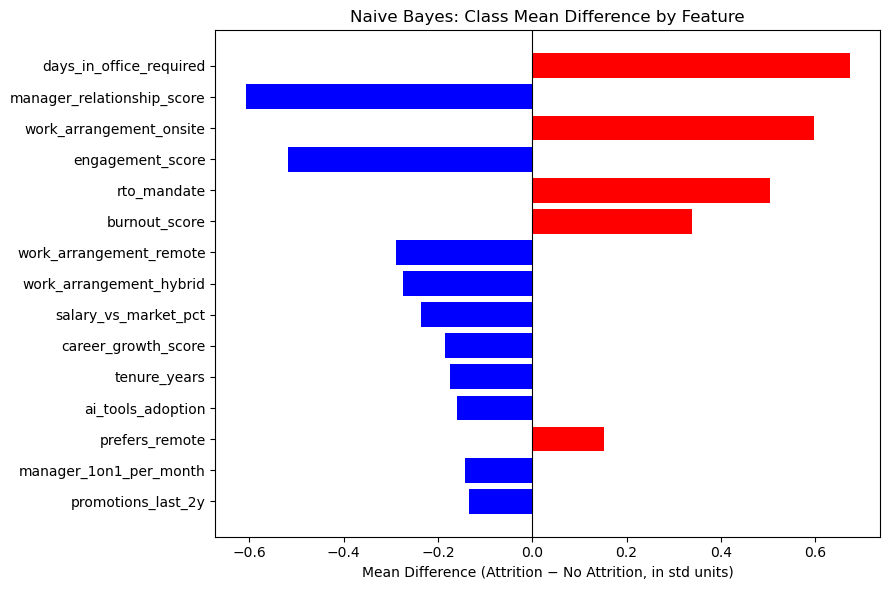

In [21]:
nb_model = final_pipeline.named_steps['nb']

feature_insight = pd.DataFrame({
    'Feature': best_features,
    'Mean_No_Attrition': nb_model.theta_[0],
    'Mean_Attrition': nb_model.theta_[1],
})
feature_insight['Mean_Difference'] = (
    feature_insight['Mean_Attrition'] - feature_insight['Mean_No_Attrition']
)
feature_insight = (
    feature_insight
    .reindex(feature_insight['Mean_Difference'].abs().sort_values(ascending=False).index)
    .reset_index(drop=True)
)

print(feature_insight.to_string(index=False))

plot_df = feature_insight.head(15).iloc[::-1]
plt.figure(figsize=(9, max(4, len(plot_df) * 0.4)))
plt.barh(
    plot_df['Feature'],
    plot_df['Mean_Difference'],
    color=['red' if v > 0 else 'blue' for v in plot_df['Mean_Difference']]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Mean Difference (Attrition − No Attrition, in std units)")
plt.title("Naive Bayes: Class Mean Difference by Feature")
plt.tight_layout()
plt.show()

## NOTES

* **สมมติฐานของ Naive Bayes:** ถือว่าทุก feature เป็นอิสระต่อกันเมื่อรู้คลาส แต่ในข้อมูลนี้มี feature ที่สัมพันธ์กันเอง เช่น `rto_mandate`, `days_in_office_required`, `work_arrangement_onsite` ทำให้ความน่าจะเป็นที่ทำนายได้อาจ "มั่นใจเกินจริง" ลำดับการจัดอันดับ (ROC-AUC) มักยังใช้ได้ดีกว่าตัวความน่าจะเป็นเอง
* **GaussianNB กับตัวแปร 0/1:** Gaussian NB สมมติให้แต่ละ feature กระจายแบบปกติ ซึ่งไม่ตรงกับตัวแปร binary/one-hot แต่ในทางปฏิบัติยังทำงานได้ ถ้าอยากต่อยอด อาจลองแยกตัวแปรต่อเนื่องใช้ GaussianNB และตัวแปร binary ใช้ BernoulliNB แล้วรวมผล
* **Balanced Prior vs SMOTE:** กับ Naive Bayes การปรับ prior ให้สมดุลมีผลคล้าย SMOTE เพราะทั้งสองวิธีเลื่อนจุดตัดสินใจไปทางคลาส Attrition แต่การปรับ prior ไม่ต้องสร้างข้อมูลสังเคราะห์ จึงเร็วกว่าและตีความง่ายกว่า
* **Undersampling vs Oversampling:** Random Undersampling ทิ้งข้อมูลคลาส No Attrition ไปประมาณ 78% ทำให้การประมาณค่าเฉลี่ยและ variance ของคลาสนั้นแม่นยำน้อยลง ส่วน Random Oversampling แค่ทำซ้ำแถวเดิม สำหรับ Gaussian NB การทำซ้ำทุกแถวในคลาสเท่ากันแทบไม่เปลี่ยนค่าเฉลี่ยและ variance จึงให้ผลใกล้เคียงกับ Balanced Prior มาก
* **80:20 vs 70:30:** ค่า CV ของสอง split คำนวณจาก training set ที่ต่างกัน (80% กับ 70% ของข้อมูล) และ test set ก็เป็นคนละชุด จึงเทียบได้ในเชิงแนวโน้ม ไม่ใช่การทดสอบบนข้อมูลเดียวกัน จาก learning curve ที่ประสิทธิภาพคงที่ตั้งแต่ประมาณ 15,000 ตัวอย่าง คาดว่าความต่างระหว่างสอง split จะน้อยมาก